# Рабочая тетрадь 8

Решены задания по кластеризации:

- k-means для заданного двумерного массива;
- эксперименты с количеством кластеров;
- k-means для набора Iris и предсказания кластеров;
- иерархическая кластеризация Iris по двум признакам.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
WORKBOOK_DIR = Path.cwd()
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
print("Рабочая папка:", WORKBOOK_DIR)

Рабочая папка: /Users/akarmain/Zed/vanilla_code


## 1. K-means для заданного массива

Метод k-средних минимизирует сумму квадратов расстояний от объектов
до центров своих кластеров. В задании нужно не только построить
кластеры, но и сравнить несколько значений `k`.

In [2]:
X = np.array([
    [5, 3],
    [10, 15],
    [15, 12],
    [24, 10],
    [30, 45],
    [85, 70],
    [71, 80],
    [60, 78],
    [55, 52],
    [80, 91],
])

experiment_rows = []
fitted_models = {}
for k in [2, 3, 4, 5]:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X)
    fitted_models[k] = (model, labels)
    experiment_rows.append(
        {
            "k": k,
            "inertia": round(model.inertia_, 2),
            "silhouette": round(silhouette_score(X, labels), 4),
            "centers": np.round(model.cluster_centers_, 2).tolist(),
        }
    )

kmeans_experiment = pd.DataFrame(experiment_rows)
display(kmeans_experiment)

,k,inertia,silhouette,centers
0,2,2964.40,0.6586,"[[16.8, 17.0], [70.2, 74.2]]"
1,3,1198.75,0.5847,"[[42.5, 48.5], [74.0, 79.75], [13.5, 10.0]]"
2,4,861.75,0.4431,"[[74.0, 79.75], [13.5, 10.0], [30.0, 45.0], [5..."
3,5,570.50,0.3422,"[[13.5, 10.0], [65.5, 79.0], [30.0, 45.0], [82..."


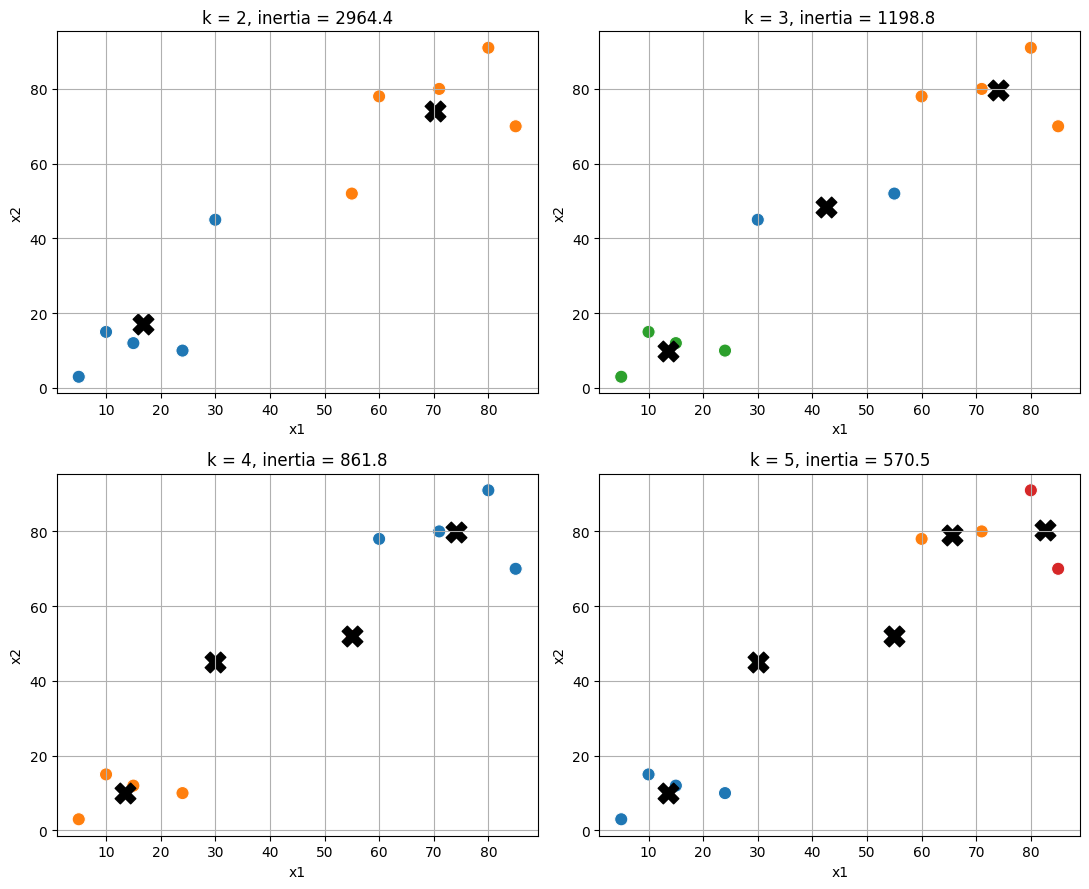

,x1,x2,cluster
0,5,3,0
1,10,15,0
2,15,12,0
3,24,10,0
4,30,45,0
5,85,70,1
6,71,80,1
7,60,78,1
8,55,52,1
9,80,91,1


Лучшее k по silhouette: 2


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.ravel()
for ax, k in zip(axes, [2, 3, 4, 5]):
    model, labels = fitted_models[k]
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="tab10", s=90, ax=ax, legend=False)
    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], marker="X", s=220, c="black")
    ax.set_title(f"k = {k}, inertia = {model.inertia_:.1f}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
plt.tight_layout()
plt.show()

best_k_simple = int(kmeans_experiment.sort_values("silhouette", ascending=False).iloc[0]["k"])
best_model_simple, best_labels_simple = fitted_models[best_k_simple]
simple_result = pd.DataFrame(X, columns=["x1", "x2"])
simple_result["cluster"] = best_labels_simple
display(simple_result)
print("Лучшее k по silhouette:", best_k_simple)

По коэффициенту silhouette лучший вариант для этого массива обычно
даёт `k = 2`: точки естественно делятся на левую и правую группы.
При увеличении `k` инерция уменьшается всегда, но это не означает,
что кластеризация становится содержательно лучше.

## 2. K-means для набора Iris

Кластеризация относится к обучению без учителя: истинные виды ириса
не передаются в модель. Метки классов используются ниже только для
внешней проверки качества через Adjusted Rand Index.

In [4]:
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()
X_iris = iris.data.to_numpy()
y_iris = iris.target.to_numpy()
X_iris_scaled = StandardScaler().fit_transform(X_iris)

iris_rows = []
iris_models = {}
for k in [2, 3, 4, 5]:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_iris_scaled)
    iris_models[k] = (model, labels)
    iris_rows.append(
        {
            "k": k,
            "inertia": round(model.inertia_, 2),
            "silhouette": round(silhouette_score(X_iris_scaled, labels), 4),
            "ARI с истинными видами": round(adjusted_rand_score(y_iris, labels), 4),
        }
    )

iris_experiment = pd.DataFrame(iris_rows)
display(iris_experiment)

kmeans_iris, iris_labels = iris_models[3]
prediction_points = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2], [6.7, 3.0, 5.2, 2.3], [5.9, 2.8, 4.2, 1.3]],
    columns=iris.feature_names,
)
scaler = StandardScaler().fit(X_iris)
kmeans_predict = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20).fit(scaler.transform(X_iris))
prediction_points["predicted_cluster"] = kmeans_predict.predict(scaler.transform(prediction_points))
display(prediction_points)

,k,inertia,silhouette,ARI с истинными видами
0,2,222.36,0.5818,0.5681
1,3,139.82,0.4599,0.6201
2,4,114.09,0.3845,0.4708
3,5,90.81,0.3455,0.4205


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),predicted_cluster
0,5.1,3.5,1.4,0.2,1
1,6.7,3.0,5.2,2.3,2
2,5.9,2.8,4.2,1.3,0


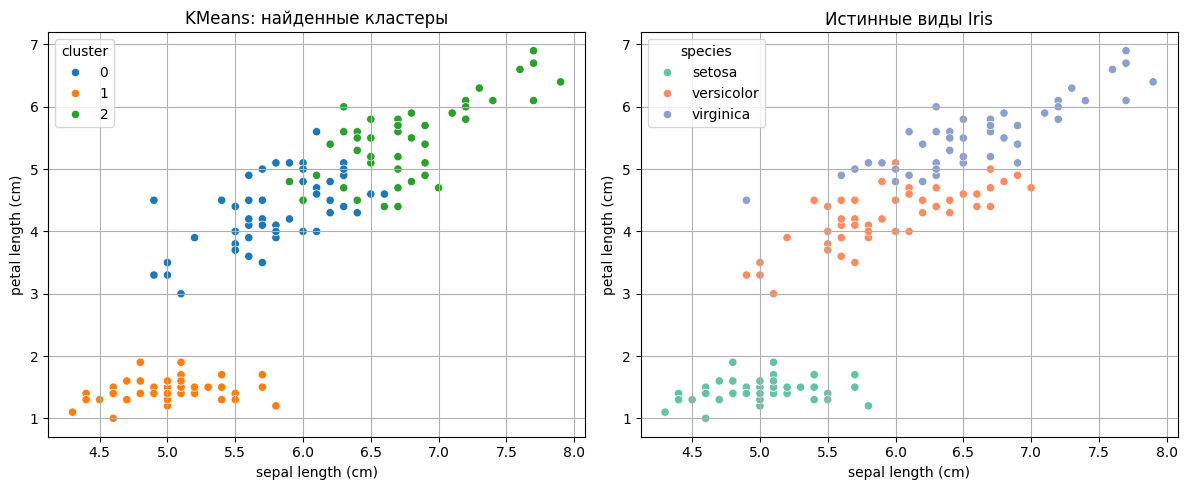

In [5]:
iris_plot = pd.DataFrame(
    {
        "sepal length (cm)": iris.data["sepal length (cm)"],
        "petal length (cm)": iris.data["petal length (cm)"],
        "cluster": iris_labels,
        "species": [iris.target_names[i] for i in y_iris],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(
    data=iris_plot,
    x="sepal length (cm)",
    y="petal length (cm)",
    hue="cluster",
    palette="tab10",
    ax=axes[0],
)
axes[0].set_title("KMeans: найденные кластеры")
sns.scatterplot(
    data=iris_plot,
    x="sepal length (cm)",
    y="petal length (cm)",
    hue="species",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Истинные виды Iris")
plt.tight_layout()
plt.show()

Для Iris естественно попробовать `k = 3`, потому что в датасете три
вида. Но k-means не знает истинных меток: он группирует объекты по
расстоянию, поэтому номера кластеров не обязаны совпадать с номерами
классов.

## 3. Иерархическая кластеризация Iris

Используем два признака: длину чашелистика и длину лепестка. Метод
`ward` объединяет кластеры так, чтобы минимально увеличить
внутрикластерную дисперсию.

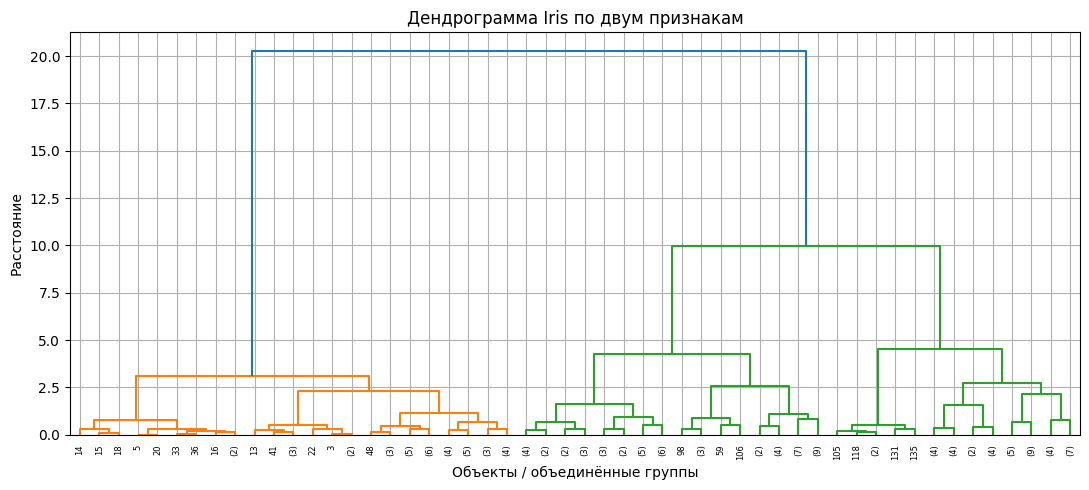

,sepal length (cm),petal length (cm),hier_cluster,species
0,5.1,1.4,1,setosa
1,4.9,1.4,1,setosa
2,4.7,1.3,1,setosa
3,4.6,1.5,1,setosa
4,5.0,1.4,1,setosa
5,5.4,1.7,1,setosa
6,4.6,1.4,1,setosa
7,5.0,1.5,1,setosa
8,4.4,1.4,1,setosa
9,4.9,1.5,1,setosa


ARI иерархической кластеризации: 0.6416


In [6]:
selected_features = ["sepal length (cm)", "petal length (cm)"]
X_hier = iris.data[selected_features].to_numpy()
X_hier_scaled = StandardScaler().fit_transform(X_hier)

Z = linkage(X_hier_scaled, method="ward")
plt.figure(figsize=(11, 5))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Дендрограмма Iris по двум признакам")
plt.xlabel("Объекты / объединённые группы")
plt.ylabel("Расстояние")
plt.tight_layout()
plt.show()

agglomerative = AgglomerativeClustering(n_clusters=3, linkage="ward")
hier_labels = agglomerative.fit_predict(X_hier_scaled)

hier_result = pd.DataFrame(X_hier, columns=selected_features)
hier_result["hier_cluster"] = hier_labels
hier_result["species"] = [iris.target_names[i] for i in y_iris]
display(hier_result.head(12))
print("ARI иерархической кластеризации:", round(adjusted_rand_score(y_iris, hier_labels), 4))

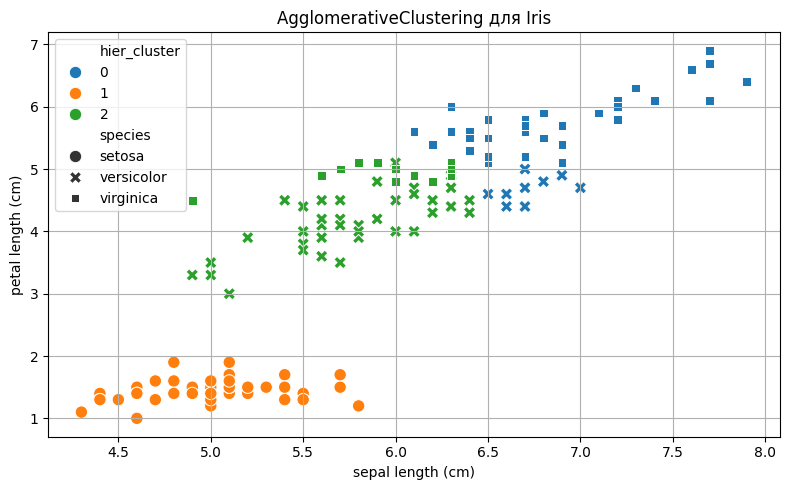

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=hier_result,
    x="sepal length (cm)",
    y="petal length (cm)",
    hue="hier_cluster",
    style="species",
    palette="tab10",
    s=80,
)
plt.title("AgglomerativeClustering для Iris")
plt.tight_layout()
plt.show()

Вывод: иерархическая кластеризация удобна тем, что через дендрограмму
можно увидеть последовательность объединений. Для Iris два выбранных
признака уже неплохо отделяют `setosa`, но два других вида частично
пересекаются, поэтому идеального совпадения с истинными классами нет.